# Classification Phase 2 - Common Experimental Protocol

**Problem:** Classify the eventual outcome as `Dropout`, `Enrolled`, or `Graduate` using information available through the end of the second semester.

**Phase boundary:** This notebook establishes the Review 1 dataset audit, EDA, cleaning decisions, feature engineering, stratified split, and leakage-safe preprocessing contract. Training and comparing the five Part-A classifiers belongs to Phase 3.

**Primary source:** [UCI Predict Students' Dropout and Academic Success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success), DOI [10.24432/C5MC89](https://doi.org/10.24432/C5MC89), CC BY 4.0.

> **Team verification gate:** Generative AI assisted with notebook scaffolding. Before evaluation, the team must rerun every cell, verify each observation against the visible output, and rewrite any interpretation that does not match its own understanding.

## 1. Reproducible setup

In [1]:
from pathlib import Path
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

def find_repo_root() -> Path:
    candidates = (Path.cwd(), *Path.cwd().parents)
    for candidate in candidates:
        if (candidate / "requirements.txt").is_file() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the capstone repository.")

ROOT = find_repo_root()
print("Repository root detected.")
print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | scikit-learn: {sklearn.__version__}")

Repository root detected.
Python: 3.13.14
pandas: 3.0.6 | scikit-learn: 1.9.1


## 2. Data loading and prediction boundary

The source file uses a semicolon delimiter. Column whitespace is normalised immediately; this removes the source tab suffix from `Daytime/evening attendance` without changing any values. Because second-semester performance is included, the prediction point is explicitly the end of the first academic year, not enrollment time.

In [2]:
DATA_PATH = ROOT / "data" / "raw" / "student_outcomes" / "data.csv"
if not DATA_PATH.is_file():
    raise FileNotFoundError(
        "Student-outcome CSV is missing. Run: python data/download_datasets.py"
    )

raw = pd.read_csv(DATA_PATH, sep=";")
raw.columns = raw.columns.str.strip()
TARGET = "Target"
PREDICTORS = [column for column in raw.columns if column != TARGET]

print(f"Raw shape: {raw.shape}")
display(raw.head())

Raw shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0000,1,19,12,5,9,127.3000,1,0,0,1,1,0,20,0,0,0,0,0,0.0000,0,0,0,0,0,0.0000,0,10.8000,1.4000,1.7400,Dropout
1,1,15,1,9254,1,1,160.0000,1,1,3,3,3,142.5000,1,0,0,0,1,0,19,0,0,6,6,6,14.0000,0,0,6,6,6,13.6667,0,13.9000,-0.3000,0.7900,Graduate
2,1,1,5,9070,1,1,122.0000,1,37,37,9,9,124.8000,1,0,0,0,1,0,19,0,0,6,0,0,0.0000,0,0,6,0,0,0.0000,0,10.8000,1.4000,1.7400,Dropout
3,1,17,2,9773,1,1,122.0000,1,38,37,5,3,119.6000,1,0,0,1,0,0,20,0,0,6,8,6,13.4286,0,0,6,10,5,12.4000,0,9.4000,-0.8000,-3.1200,Graduate
4,2,39,1,8014,0,1,100.0000,1,37,38,9,9,141.5000,0,0,0,1,0,0,45,0,0,6,9,5,12.3333,0,0,6,6,6,13.0000,0,13.9000,-0.3000,0.7900,Graduate


**Observation:** The table contains 4,424 students, 36 predictors, and one three-class target. There is no free-text identifier or direct student ID. Integer codes such as `Course` and `Application mode` represent categories rather than numeric magnitudes and must not be standardised as continuous measurements.

## 3. Dataset audit

In [3]:
audit = pd.DataFrame(
    {
        "dtype": raw.dtypes.astype(str),
        "missing": raw.isna().sum(),
        "unique": raw.nunique(dropna=False),
    }
)
display(audit)
print(f"Missing values: {int(raw.isna().sum().sum())}")
print(f"Exact duplicate rows: {int(raw.duplicated().sum())}")

class_counts = raw[TARGET].value_counts().reindex(["Dropout", "Enrolled", "Graduate"])
class_audit = pd.DataFrame(
    {"rows": class_counts, "share_pct": 100 * class_counts / len(raw)}
)
display(class_audit)

,dtype,missing,unique
Marital status,int64,0,6
Application mode,int64,0,18
Application order,int64,0,8
Course,int64,0,17
Daytime/evening attendance,int64,0,2
Previous qualification,int64,0,17
Previous qualification (grade),float64,0,101
Nacionality,int64,0,21
Mother's qualification,int64,0,29
Father's qualification,int64,0,34


Missing values: 0
Exact duplicate rows: 0


,rows,share_pct
Target,,
Dropout,1421,32.1203
Enrolled,794,17.9476
Graduate,2209,49.9322


**Observation:** The source has no missing values and no exact duplicate rows. The target is imbalanced: `Graduate` is the largest class, while `Enrolled` is the smallest. Phase 3 must therefore report macro F1 and per-class recall alongside weighted metrics so performance on `Enrolled` is not hidden.

## 4. Target and predictor distributions

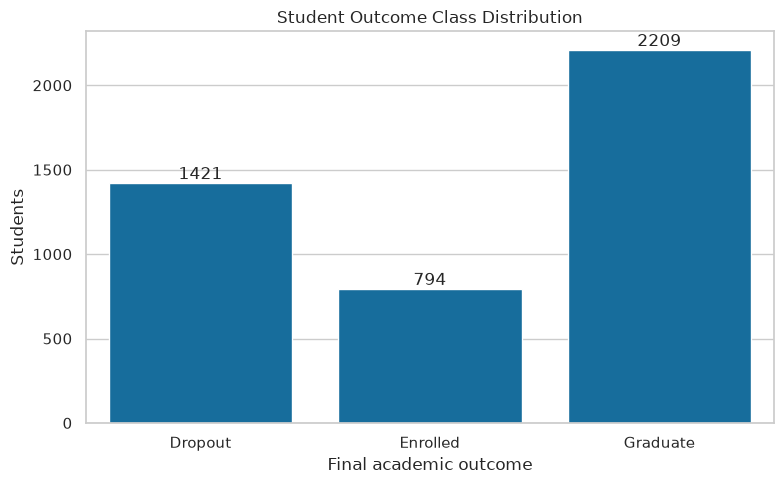

In [4]:
plt.figure(figsize=(8, 5))
axis = sns.countplot(data=raw, x=TARGET, order=["Dropout", "Enrolled", "Graduate"])
axis.set_title("Student Outcome Class Distribution")
axis.set_xlabel("Final academic outcome")
axis.set_ylabel("Students")
for container in axis.containers:
    axis.bar_label(container)
plt.tight_layout()
plt.show()

**Observation:** Nearly half of the records are `Graduate`, and `Enrolled` has only 794 observations. A stratified split is necessary to preserve these proportions, but stratification alone does not solve the difficulty of the minority class.

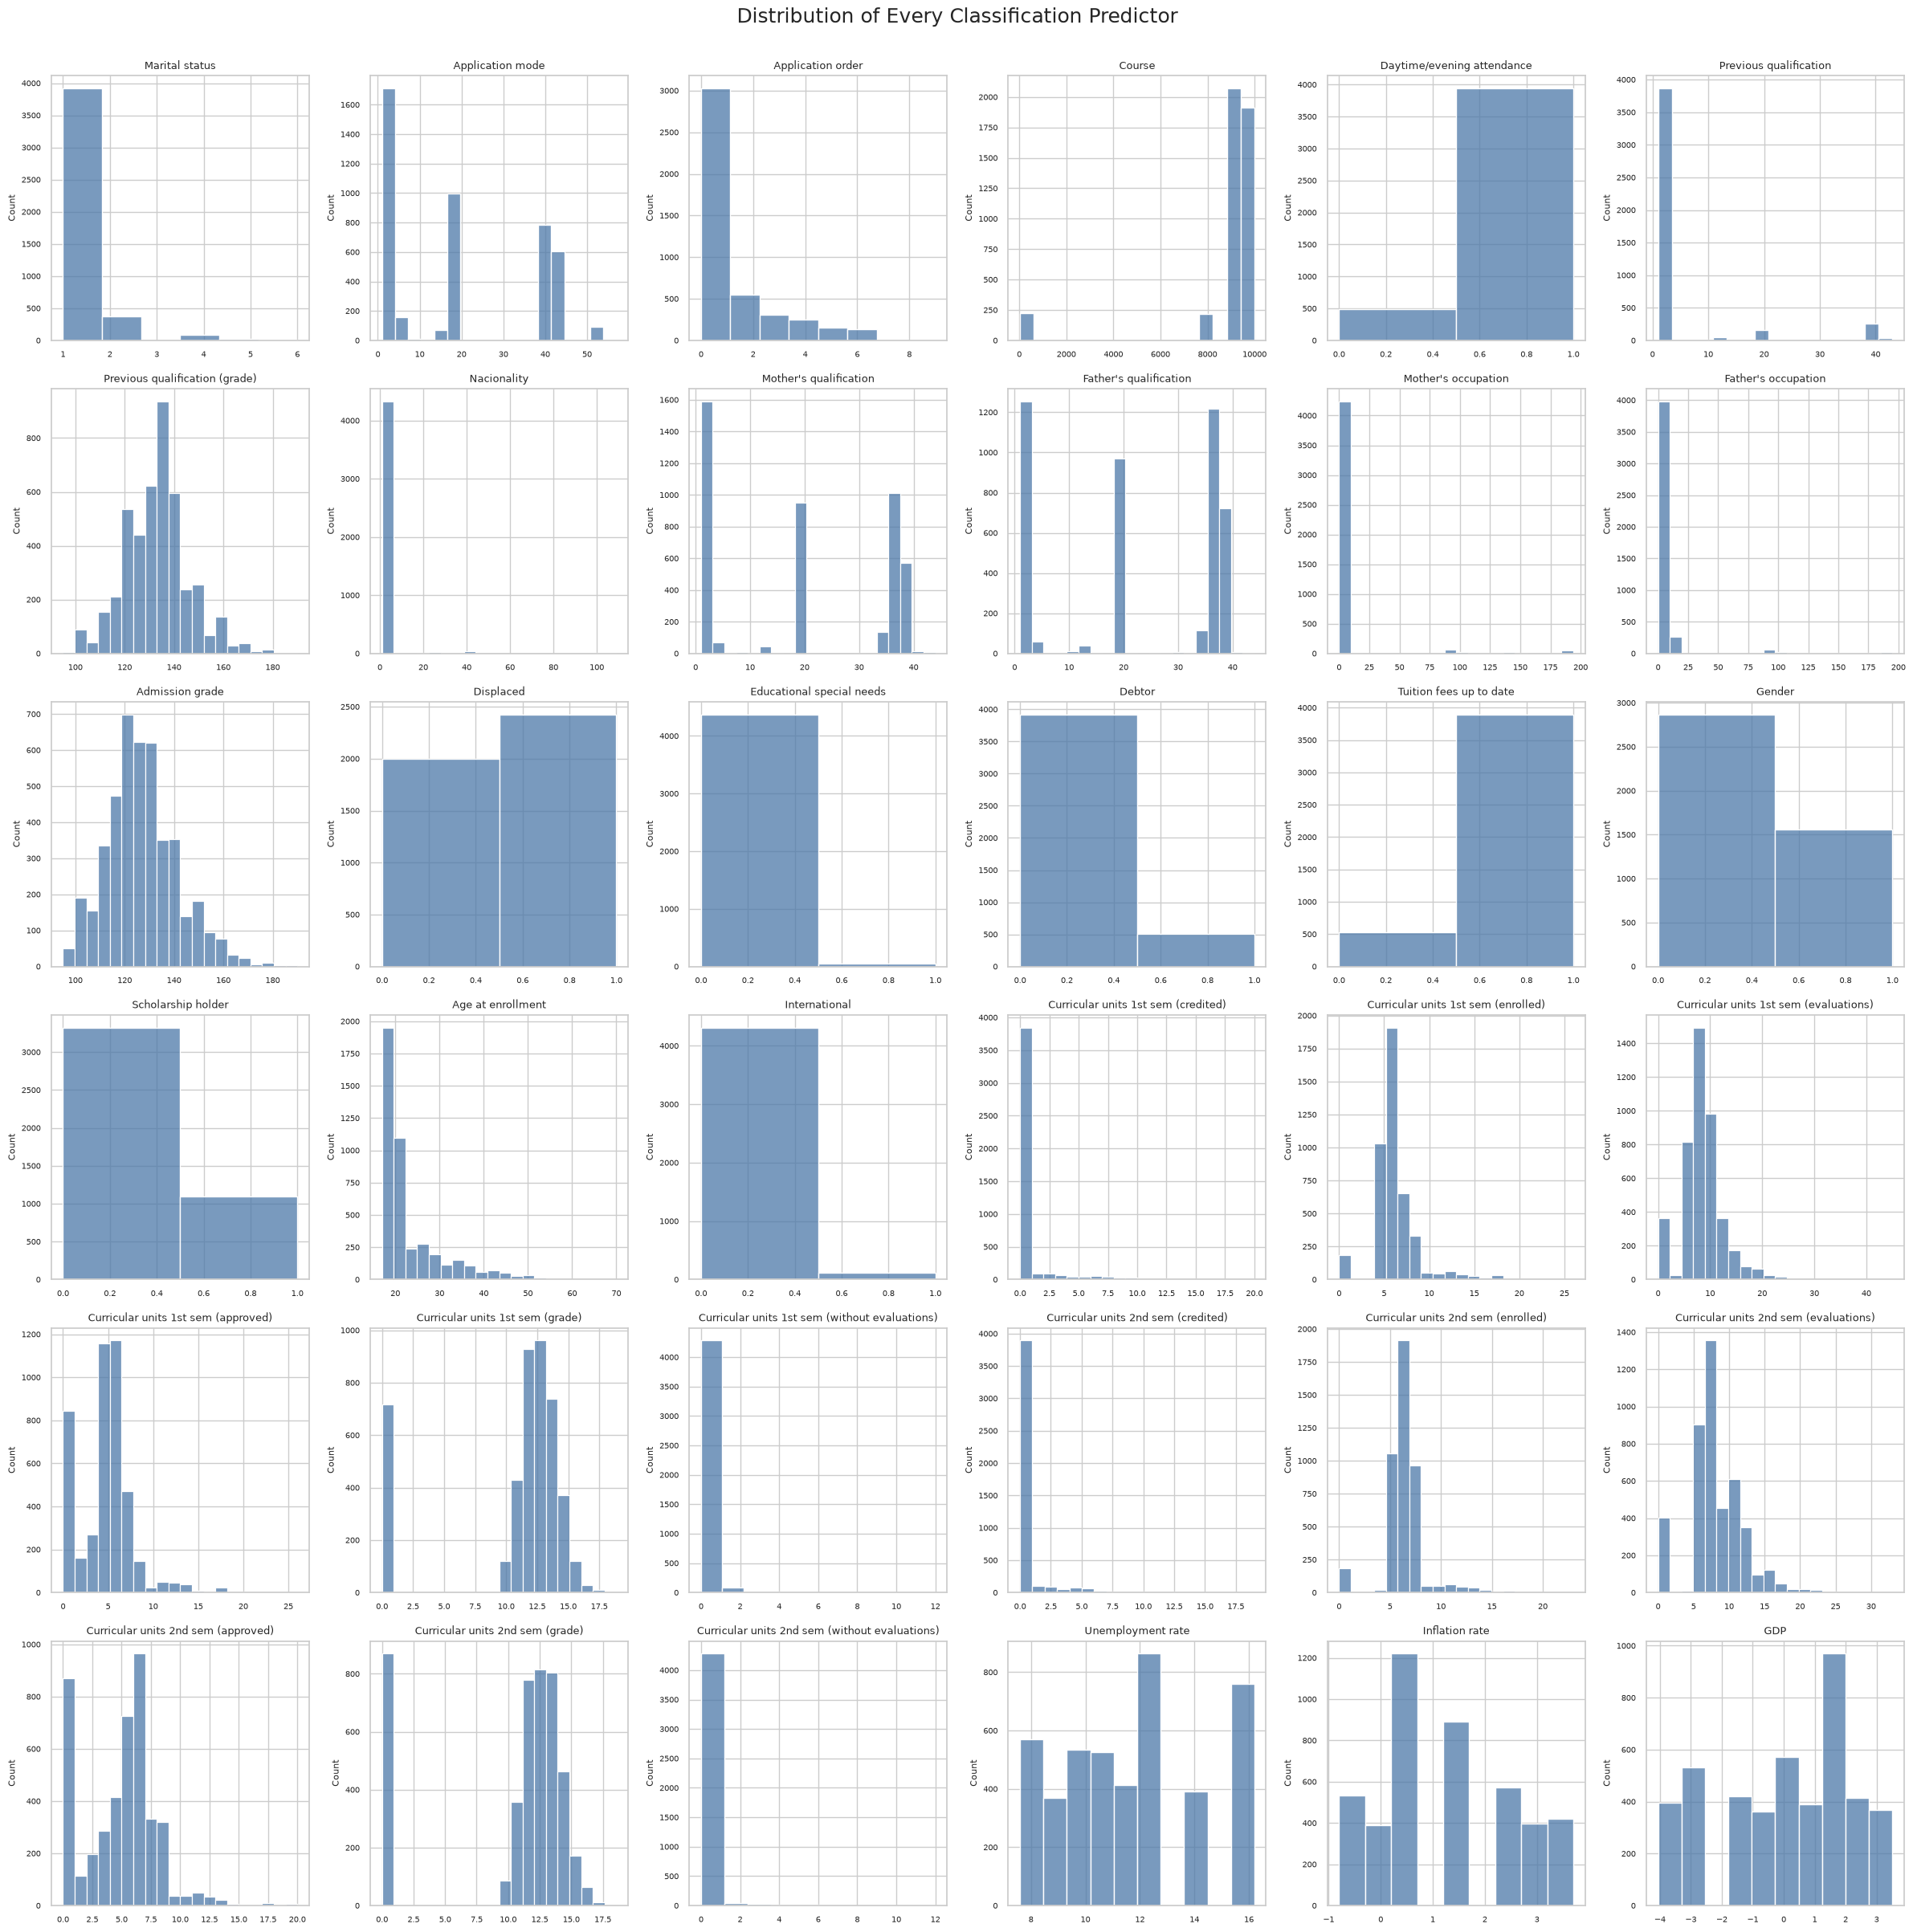

In [5]:
fig, axes = plt.subplots(6, 6, figsize=(24, 24))
for axis, column in zip(axes.flat, PREDICTORS, strict=True):
    values = raw[column]
    bins = min(20, max(2, values.nunique()))
    sns.histplot(values, bins=bins, ax=axis, color="#4C78A8")
    axis.set_title(column, fontsize=9)
    axis.set_xlabel("")
    axis.set_ylabel("Count", fontsize=8)
    axis.tick_params(axis="both", labelsize=7)
fig.suptitle("Distribution of Every Classification Predictor", fontsize=18, y=1.002)
plt.tight_layout()
plt.show()

**Observation:** Several curricular-unit variables are zero-inflated, while many administrative fields have discrete code patterns. These plots are frequency audits, not evidence that category codes have ordinal distance. The preprocessing contract therefore one-hot encodes declared categoricals and scales only genuinely numeric measures.

## 5. Numeric association audit

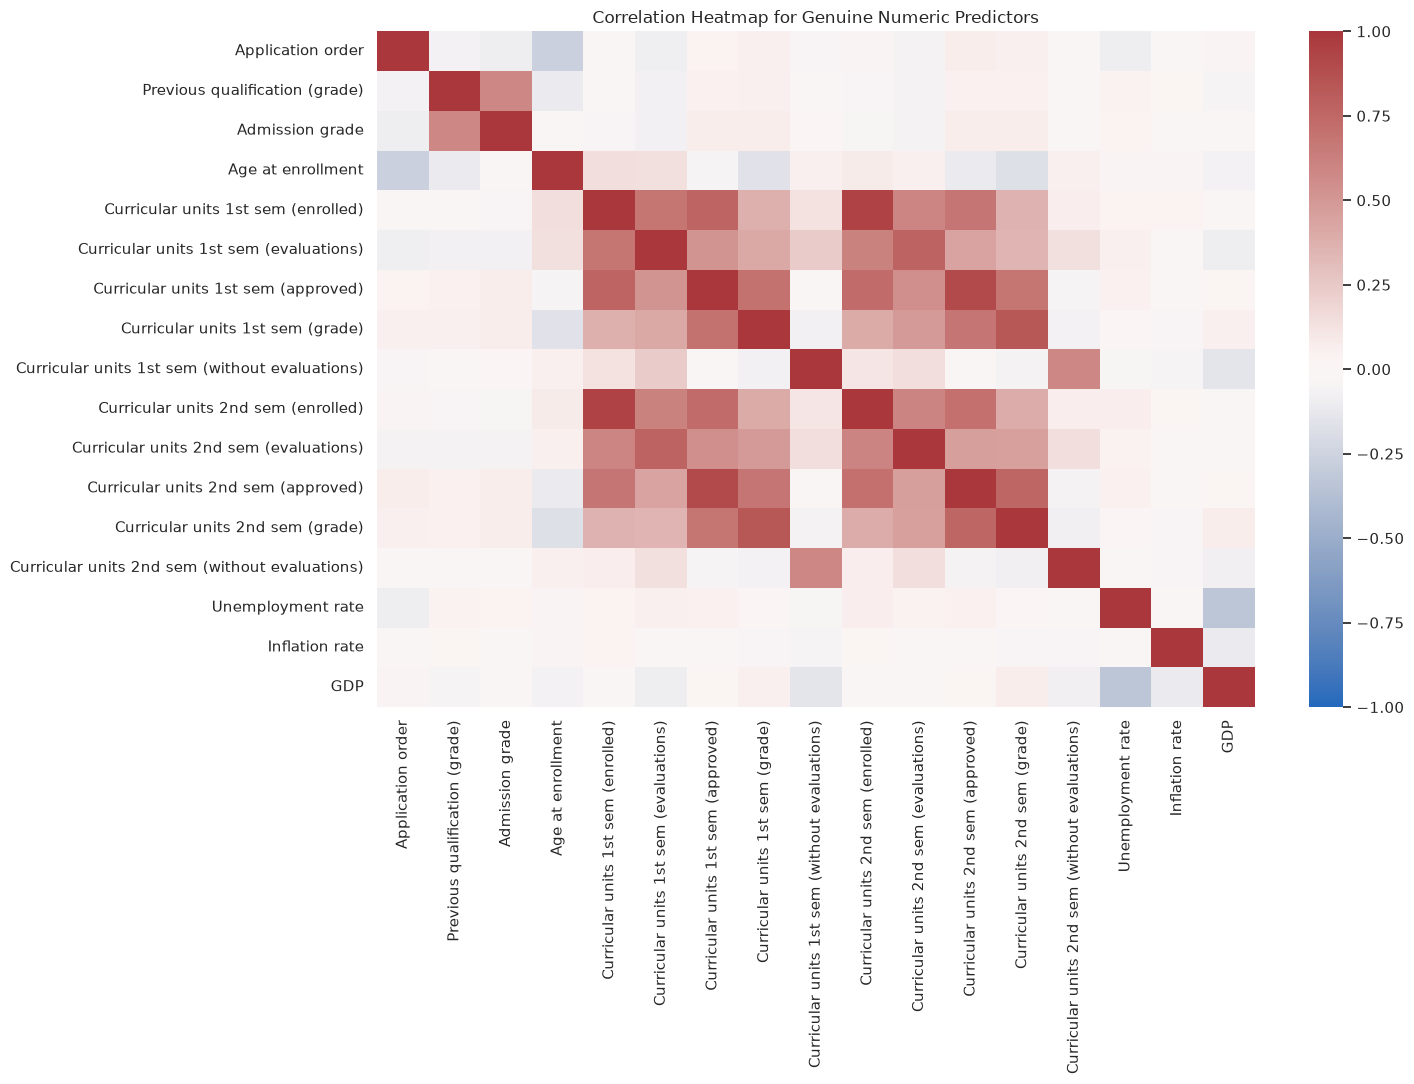

In [6]:
NUMERIC_FOR_CORRELATION = [
    "Application order",
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)",
    "Unemployment rate",
    "Inflation rate",
    "GDP",
]
corr = raw[NUMERIC_FOR_CORRELATION].corr()
plt.figure(figsize=(15, 11))
sns.heatmap(corr, cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Correlation Heatmap for Genuine Numeric Predictors")
plt.tight_layout()
plt.show()

**Observation:** Enrollment, evaluation, approval, and grade counts within each semester are related, but they measure different stages of academic progress. The heatmap intentionally excludes integer-coded nominal categories because Pearson correlation on arbitrary category numbers would be misleading.

## 6. Feature-target relationships

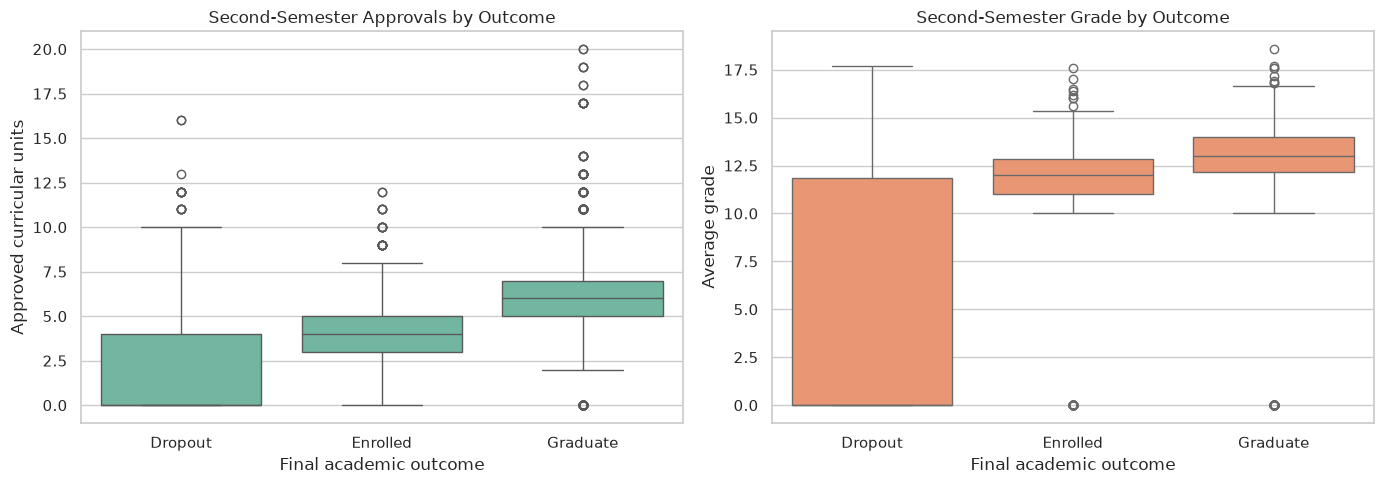

In [7]:
class_order = ["Dropout", "Enrolled", "Graduate"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(
    data=raw,
    x=TARGET,
    y="Curricular units 2nd sem (approved)",
    order=class_order,
    color="#66C2A5",
    ax=axes[0],
)
axes[0].set_title("Second-Semester Approvals by Outcome")
axes[0].set_xlabel("Final academic outcome")
axes[0].set_ylabel("Approved curricular units")
sns.boxplot(
    data=raw,
    x=TARGET,
    y="Curricular units 2nd sem (grade)",
    order=class_order,
    color="#FC8D62",
    ax=axes[1],
)
axes[1].set_title("Second-Semester Grade by Outcome")
axes[1].set_xlabel("Final academic outcome")
axes[1].set_ylabel("Average grade")
plt.tight_layout()
plt.show()

**Observation:** Graduates generally have more approved second-semester units and higher grades, whereas zero approvals and zero grades occur more often among dropouts. The class distributions still overlap, so neither feature can decide the outcome alone. These are predictive associations measured after semester two, not causal explanations of student success.

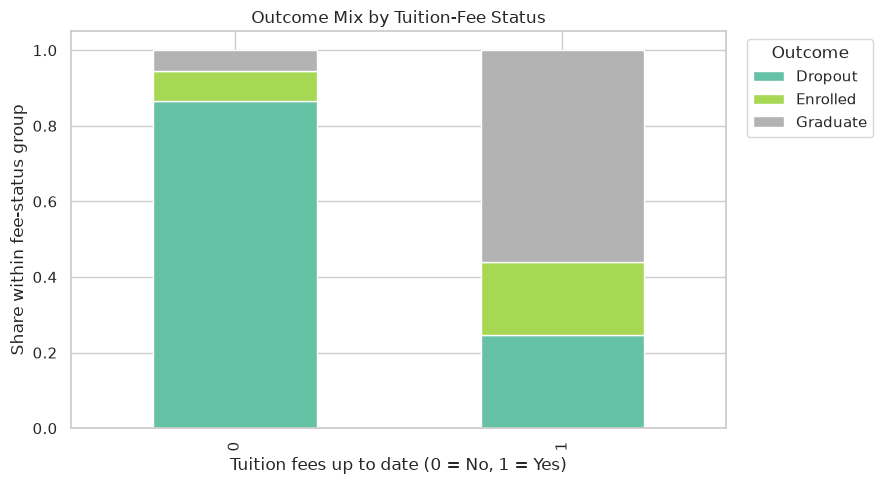

In [8]:
approval_table = pd.crosstab(
    raw["Tuition fees up to date"], raw[TARGET], normalize="index"
).reindex(columns=class_order)
approval_table.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="Set2")
plt.title("Outcome Mix by Tuition-Fee Status")
plt.xlabel("Tuition fees up to date (0 = No, 1 = Yes)")
plt.ylabel("Share within fee-status group")
plt.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Observation:** The outcome mix differs visibly by fee-status group, making financial status potentially useful for support-oriented prediction. It must not be interpreted as proof that fee status causes dropout, and model outputs must not be used for automated punitive decisions.

## 7. Outlier audit

In [9]:
def iqr_audit(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    records = []
    for column in columns:
        q1, q3 = frame[column].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        flagged = frame[column].lt(lower) | frame[column].gt(upper)
        records.append(
            {
                "feature": column,
                "lower_fence": lower,
                "upper_fence": upper,
                "flagged_rows": int(flagged.sum()),
                "flagged_share_pct": 100 * flagged.mean(),
                "observed_min": frame[column].min(),
                "observed_max": frame[column].max(),
            }
        )
    return pd.DataFrame(records).set_index("feature")

student_outlier_audit = iqr_audit(raw, NUMERIC_FOR_CORRELATION)
display(student_outlier_audit.sort_values("flagged_share_pct", ascending=False))

,lower_fence,upper_fence,flagged_rows,flagged_share_pct,observed_min,observed_max
feature,,,,,,
Curricular units 2nd sem (grade),6.8750,17.2083,877,19.8237,0.0000,18.5714
Curricular units 1st sem (grade),7.4000,17.0000,726,16.4105,0.0000,18.8750
Application order,-0.5000,3.5000,541,12.2288,0.0000,9.0000
Age at enrollment,10.0000,34.0000,441,9.9684,17.0000,70.0000
Curricular units 1st sem (enrolled),2.0000,10.0000,424,9.5841,0.0000,26.0000
Curricular units 2nd sem (enrolled),2.0000,10.0000,369,8.3409,0.0000,23.0000
Curricular units 1st sem (without evaluations),0.0000,0.0000,294,6.6456,0.0000,12.0000
Curricular units 2nd sem (without evaluations),0.0000,0.0000,282,6.3743,0.0000,12.0000
Curricular units 1st sem (approved),-1.5000,10.5000,180,4.0687,0.0000,26.0000


**Decision:** Phase 2 does not delete students solely for crossing an IQR fence. Rare ages, grades, and study histories may be legitimate and are part of the population the support model should understand. Categorical codes are excluded from the outlier calculation because a rare category is not a numeric outlier. Scaling and imputation remain inside the model pipeline.

## 8. Cleaning and deterministic feature engineering

In [10]:
clean = raw.drop_duplicates().reset_index(drop=True).copy()
assert len(clean) == len(raw)
assert clean.isna().sum().sum() == 0

def safe_ratio(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    return pd.Series(
        np.divide(
            numerator,
            denominator,
            out=np.zeros(len(numerator), dtype=float),
            where=denominator.to_numpy() != 0,
        ),
        index=numerator.index,
    )

def add_student_features(frame: pd.DataFrame) -> pd.DataFrame:
    # Row-wise academic progress features available after semester two.
    engineered = frame.copy()
    engineered["approval_ratio_1st"] = safe_ratio(
        engineered["Curricular units 1st sem (approved)"],
        engineered["Curricular units 1st sem (enrolled)"],
    )
    engineered["approval_ratio_2nd"] = safe_ratio(
        engineered["Curricular units 2nd sem (approved)"],
        engineered["Curricular units 2nd sem (enrolled)"],
    )
    engineered["approval_ratio_change"] = (
        engineered["approval_ratio_2nd"] - engineered["approval_ratio_1st"]
    )
    engineered["semester_grade_change"] = (
        engineered["Curricular units 2nd sem (grade)"]
        - engineered["Curricular units 1st sem (grade)"]
    )
    return engineered

model_data = add_student_features(clean)
ENGINEERED_FEATURES = [
    "approval_ratio_1st",
    "approval_ratio_2nd",
    "approval_ratio_change",
    "semester_grade_change",
]
display(model_data[ENGINEERED_FEATURES].describe().T)

,count,mean,std,min,25%,50%,75%,max
approval_ratio_1st,"4,424.0000",0.6979,0.3652,0.0000,0.5000,0.8333,1.0000,1.0000
approval_ratio_2nd,"4,424.0000",0.6604,0.3830,0.0000,0.4000,0.8333,1.0000,1.0000
approval_ratio_change,"4,424.0000",-0.0375,0.1894,-1.0000,-0.0076,0.0000,0.0000,1.0000
semester_grade_change,"4,424.0000",-0.4106,2.8904,-16.1429,-0.6000,0.0000,0.4524,16.0000


**Justification:** Approval ratios compare completed success with the number of units attempted and remain interpretable across different course loads. Their change, together with grade change, captures direction between semesters. Each feature is deterministic, uses only information available by the declared prediction point, and handles zero enrolled units without division errors. Phase 3 must confirm value through training-only validation.

## 9. Stratified train/test split

In [11]:
from sklearn.model_selection import train_test_split

X = model_data.drop(columns=TARGET)
y = model_data[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_counts = pd.concat(
    {
        "training": y_train.value_counts().reindex(class_order),
        "test": y_test.value_counts().reindex(class_order),
    },
    axis=1,
)
split_counts["training_share_pct"] = 100 * split_counts["training"] / len(y_train)
split_counts["test_share_pct"] = 100 * split_counts["test"] / len(y_test)
display(split_counts)
print(f"Training rows: {len(X_train):,} | Final test rows: {len(X_test):,}")
assert len(X_train) == 3_539 and len(X_test) == 885

,training,test,training_share_pct,test_share_pct
Target,,,,
Dropout,1137,284,32.1277,32.0904
Enrolled,635,159,17.9429,17.9661
Graduate,1767,442,49.9294,49.9435


Training rows: 3,539 | Final test rows: 885


**Decision:** One fixed, stratified 80:20 split is shared by all five Part-A classifiers. The 885 test students remain untouched during feature selection and tuning. `random_state=42` makes the exact observations reproducible across every model.

## 10. Leakage-safe preprocessing contract

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

CATEGORICAL_FEATURES = [
    "Marital status",
    "Application mode",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International",
]
NUMERIC_FEATURES = [
    column
    for column in X_train.columns
    if column not in CATEGORICAL_FEATURES
]
assert set(CATEGORICAL_FEATURES).isdisjoint(NUMERIC_FEATURES)
assert set(CATEGORICAL_FEATURES + NUMERIC_FEATURES) == set(X_train.columns)

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)
classification_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, NUMERIC_FEATURES),
        ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# Protocol validation only. Phase 3 must clone this object inside every model
# pipeline so imputation, scaling, and encoding are learned inside each CV fold.
X_train_prepared = classification_preprocessor.fit_transform(X_train)
X_test_prepared = classification_preprocessor.transform(X_test)
prepared_names = classification_preprocessor.get_feature_names_out()

print(f"Declared numeric features: {len(NUMERIC_FEATURES)}")
print(f"Declared categorical features: {len(CATEGORICAL_FEATURES)}")
print(f"Prepared training shape: {X_train_prepared.shape}")
print(f"Prepared test shape: {X_test_prepared.shape}")
print(f"Finite training values: {np.isfinite(X_train_prepared).all()}")
print(f"Finite test values: {np.isfinite(X_test_prepared).all()}")
display(pd.Series(prepared_names, name="prepared_feature").head(25).to_frame())

Declared numeric features: 23
Declared categorical features: 17
Prepared training shape: (3539, 248)
Prepared test shape: (885, 248)
Finite training values: True
Finite test values: True


,prepared_feature
0,Application order
1,Previous qualification (grade)
2,Admission grade
3,Age at enrollment
4,Curricular units 1st sem (credited)
5,Curricular units 1st sem (enrolled)
6,Curricular units 1st sem (evaluations)
7,Curricular units 1st sem (approved)
8,Curricular units 1st sem (grade)
9,Curricular units 1st sem (without evaluations)


**Decision:** Nominal integer codes are one-hot encoded, while genuine numeric variables and engineered ratios are median-imputed and standardised. `handle_unknown="ignore"` allows a category present only in later data to be represented safely. A dense matrix keeps the same preprocessing compatible with Gaussian Naive Bayes as well as Logistic Regression, KNN, Decision Tree, and SVC.

In [13]:
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fold_records = []
for fold, (fit_idx, validation_idx) in enumerate(
    stratified_cv.split(X_train, y_train), start=1
):
    fit_counts = y_train.iloc[fit_idx].value_counts().reindex(class_order)
    validation_counts = y_train.iloc[validation_idx].value_counts().reindex(class_order)
    record = {"fold": fold, "fit_rows": len(fit_idx), "validation_rows": len(validation_idx)}
    for label in class_order:
        record[f"validation_{label}"] = int(validation_counts[label])
    fold_records.append(record)
fold_summary = pd.DataFrame(fold_records).set_index("fold")
display(fold_summary)

,fit_rows,validation_rows,validation_Dropout,validation_Enrolled,validation_Graduate
fold,,,,,
1,2831,708,227,127,354
2,2831,708,227,127,354
3,2831,708,228,127,353
4,2831,708,228,127,353
5,2832,707,227,127,353


**Cross-validation contract:** Five shuffled, stratified folds preserve all three classes in every validation fold. Phase 3 hyperparameter searches must receive a complete estimator pipeline, not an already transformed full training matrix, so fold-level preprocessing remains leakage-safe.

## 11. Phase 2 classification handoff

Phase 3 must reuse this exact split, feature grouping, deterministic engineering, and `StratifiedKFold`. It must train all five Part-A algorithms on the same training observations and report Accuracy, weighted Precision/Recall/F1, macro F1, per-class precision and recall, confusion matrices, and multiclass OvR ROC-AUC. The test set must remain outside all tuning decisions.

# Phase 3 - Classification Part A Modeling and Evaluation

Phase 3 trains all five required classifiers on the same fixed 80% training observations. Feature choice and hyperparameters use only five-fold stratified training CV with macro F1 as the selection score because the `Enrolled` class is the smallest. The untouched 885-student test set is evaluated only after all searches finish.

> **Team verification gate:** The team must rerun this notebook, verify every displayed value and interpretation, and explain the preprocessing, metrics, assumptions, and hyperparameters during the viva.

## 12. Training-only engineered-feature decision

In [14]:
from time import perf_counter

from IPython.display import Markdown
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

def build_classification_preprocessor(feature_columns):
    categorical = [column for column in CATEGORICAL_FEATURES if column in feature_columns]
    numeric = [column for column in feature_columns if column not in categorical]
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric),
            ("categorical", categorical_pipeline, categorical),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

def make_classification_pipeline(model, feature_columns):
    return Pipeline(
        steps=[
            ("preprocessor", build_classification_preprocessor(feature_columns)),
            ("model", model),
        ]
    )

BASE_CLASSIFICATION_FEATURES = PREDICTORS.copy()
FEATURE_SET_CANDIDATES = {
    "Approved raw features": BASE_CLASSIFICATION_FEATURES,
    "Raw + approval-ratio change": BASE_CLASSIFICATION_FEATURES + ["approval_ratio_change"],
}
feature_cv_rows = []
for feature_set, columns in FEATURE_SET_CANDIDATES.items():
    estimator = make_classification_pipeline(
        LogisticRegression(max_iter=5_000, random_state=RANDOM_STATE),
        columns,
    )
    scores = cross_val_score(
        estimator,
        X_train[columns],
        y_train,
        cv=stratified_cv,
        scoring="f1_macro",
        n_jobs=-1,
        error_score="raise",
    )
    feature_cv_rows.append(
        {
            "Feature set": feature_set,
            "Mean CV Macro F1": scores.mean(),
            "Std CV Macro F1": scores.std(),
            "Fold Macro F1": np.round(scores, 6).tolist(),
        }
    )

classification_feature_selection = (
    pd.DataFrame(feature_cv_rows)
    .sort_values("Mean CV Macro F1", ascending=False)
    .reset_index(drop=True)
)
display(classification_feature_selection)

SELECTED_CLASSIFICATION_FEATURES = FEATURE_SET_CANDIDATES[
    classification_feature_selection.iloc[0]["Feature set"]
]
X_train_model = X_train[SELECTED_CLASSIFICATION_FEATURES].copy()
X_test_model = X_test[SELECTED_CLASSIFICATION_FEATURES].copy()

display(
    Markdown(
        f"**Decision:** `{classification_feature_selection.iloc[0]['Feature set']}` is "
        f"retained with mean training-CV macro F1 "
        f"`{classification_feature_selection.iloc[0]['Mean CV Macro F1']:.6f}` versus "
        f"`{classification_feature_selection.iloc[1]['Mean CV Macro F1']:.6f}`. "
        "Only `approval_ratio_change` is carried into modeling; the other engineered "
        "features remain documented but did not improve this linear training-CV check."
    )
)

,Feature set,Mean CV Macro F1,Std CV Macro F1,Fold Macro F1
0,Raw + approval-ratio change,0.7029,0.0131,"[0.727301, 0.697131, 0.697813, 0.703513, 0.688..."
1,Approved raw features,0.7020,0.0141,"[0.728764, 0.691402, 0.69443, 0.703513, 0.691675]"


**Decision:** `Raw + approval-ratio change` is retained with mean training-CV macro F1 `0.702919` versus `0.701957`. Only `approval_ratio_change` is carried into modeling; the other engineered features remain documented but did not improve this linear training-CV check.

## 13. Shared search protocol

All searches optimise macro F1, which gives each outcome class equal weight. This prevents the larger `Graduate` class from deciding every hyperparameter choice. Each `GridSearchCV` object contains the complete preprocessing pipeline, so scaling and one-hot encoding are relearned inside every fold.

In [15]:
classification_estimators = {}
classification_cv_records = []
classification_search_records = []

def register_classifier(name, estimator, parameter_grid):
    started = perf_counter()
    search = GridSearchCV(
        estimator=estimator,
        param_grid=parameter_grid,
        scoring="f1_macro",
        cv=stratified_cv,
        n_jobs=-1,
        refit=True,
        error_score="raise",
        return_train_score=False,
    )
    search.fit(X_train_model, y_train)
    elapsed = perf_counter() - started
    classification_estimators[name] = search.best_estimator_
    classification_cv_records.append(
        {
            "Model": name,
            "CV Mean Macro F1": search.best_score_,
            "CV Std Macro F1": search.cv_results_["std_test_score"][search.best_index_],
            "Search Seconds": elapsed,
        }
    )
    classification_search_records.append(
        {
            "Model": name,
            "Best Parameters": search.best_params_,
            "Candidates": len(search.cv_results_["params"]),
        }
    )
    print(f"Completed {name} in {elapsed:.1f}s | {search.best_params_}")

## 14. Five required Classification Part A algorithms

In [16]:
register_classifier(
    "Logistic Regression",
    make_classification_pipeline(
        LogisticRegression(max_iter=5_000, random_state=RANDOM_STATE),
        SELECTED_CLASSIFICATION_FEATURES,
    ),
    {
        "model__C": [0.1, 1.0, 10.0],
        "model__class_weight": [None, "balanced"],
    },
)

register_classifier(
    "K-Nearest Neighbors",
    make_classification_pipeline(
        KNeighborsClassifier(),
        SELECTED_CLASSIFICATION_FEATURES,
    ),
    {
        "model__n_neighbors": [5, 11, 21, 31],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2],
    },
)

register_classifier(
    "Gaussian Naive Bayes",
    make_classification_pipeline(
        GaussianNB(),
        SELECTED_CLASSIFICATION_FEATURES,
    ),
    {"model__var_smoothing": [1e-11, 1e-9, 1e-7]},
)

register_classifier(
    "Decision Tree Classifier",
    make_classification_pipeline(
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        SELECTED_CLASSIFICATION_FEATURES,
    ),
    {
        "model__max_depth": [4, 6, 8, None],
        "model__min_samples_leaf": [5, 15],
        "model__criterion": ["gini", "entropy"],
    },
)

register_classifier(
    "Support Vector Classifier",
    make_classification_pipeline(
        SVC(decision_function_shape="ovr", cache_size=2_000, random_state=RANDOM_STATE),
        SELECTED_CLASSIFICATION_FEATURES,
    ),
    {
        "model__C": [0.1, 1.0, 10.0],
        "model__kernel": ["linear", "rbf"],
        "model__class_weight": [None, "balanced"],
    },
)

Completed Logistic Regression in 2.4s | {'model__C': 0.1, 'model__class_weight': 'balanced'}


Completed K-Nearest Neighbors in 1.6s | {'model__n_neighbors': 5, 'model__p': 1, 'model__weights': 'uniform'}
Completed Gaussian Naive Bayes in 0.2s | {'model__var_smoothing': 1e-07}


Completed Decision Tree Classifier in 0.5s | {'model__criterion': 'gini', 'model__max_depth': 6, 'model__min_samples_leaf': 5}


Completed Support Vector Classifier in 10.9s | {'model__C': 1.0, 'model__class_weight': 'balanced', 'model__kernel': 'rbf'}


In [17]:
classification_cv_table = (
    pd.DataFrame(classification_cv_records)
    .sort_values("CV Mean Macro F1", ascending=False)
    .reset_index(drop=True)
)
classification_parameter_table = pd.DataFrame(classification_search_records)
display(classification_cv_table.style.format({
    "CV Mean Macro F1": "{:.6f}",
    "CV Std Macro F1": "{:.6f}",
    "Search Seconds": "{:.1f}",
}))
display(classification_parameter_table)

,Model,CV Mean Macro F1,CV Std Macro F1,Search Seconds
0,Support Vector Classifier,0.715701,0.015749,10.9
1,Logistic Regression,0.714371,0.015983,2.4
2,Decision Tree Classifier,0.667895,0.011186,0.5
3,K-Nearest Neighbors,0.626740,0.012415,1.6
4,Gaussian Naive Bayes,0.229552,0.013532,0.2


,Model,Best Parameters,Candidates
0,Logistic Regression,"{'model__C': 0.1, 'model__class_weight': 'bala...",6
1,K-Nearest Neighbors,"{'model__n_neighbors': 5, 'model__p': 1, 'mode...",16
2,Gaussian Naive Bayes,{'model__var_smoothing': 1e-07},3
3,Decision Tree Classifier,"{'model__criterion': 'gini', 'model__max_depth...",16
4,Support Vector Classifier,"{'model__C': 1.0, 'model__class_weight': 'bala...",12


**Algorithm notes:** KNN tuning compares neighborhood size, uniform versus distance weighting, and Manhattan versus Euclidean distance. Gaussian Naive Bayes assumes conditional independence of transformed features within each class, an approximation that is visibly imperfect for related semester variables. Decision Tree tuning controls depth and leaf size. SVC receives scaled numeric inputs and explicitly searches both `C` and kernel.

## 15. Final held-out comparison

In [18]:
def aligned_class_scores(estimator, features, labels):
    if hasattr(estimator, "predict_proba"):
        raw_scores = estimator.predict_proba(features)
    else:
        raw_scores = estimator.decision_function(features)
    estimator_classes = list(estimator.classes_)
    return np.column_stack(
        [raw_scores[:, estimator_classes.index(label)] for label in labels]
    )

y_test_binary = label_binarize(y_test, classes=class_order)
class_support = y_test.value_counts().reindex(class_order).to_numpy()
classification_predictions = {}
classification_scores = {}
comparison_rows = []
per_class_rows = []

for name, estimator in classification_estimators.items():
    predictions = estimator.predict(X_test_model)
    scores = aligned_class_scores(estimator, X_test_model, class_order)
    classification_predictions[name] = predictions
    classification_scores[name] = scores

    class_aucs = [
        roc_auc_score(y_test_binary[:, index], scores[:, index])
        for index in range(len(class_order))
    ]
    report = classification_report(
        y_test,
        predictions,
        labels=class_order,
        output_dict=True,
        zero_division=0,
    )
    comparison_rows.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_test, predictions),
            "Weighted Precision": precision_score(y_test, predictions, average="weighted", zero_division=0),
            "Weighted Recall": recall_score(y_test, predictions, average="weighted", zero_division=0),
            "Weighted F1": f1_score(y_test, predictions, average="weighted", zero_division=0),
            "Macro F1": f1_score(y_test, predictions, average="macro", zero_division=0),
            "Weighted OvR ROC-AUC": np.average(class_aucs, weights=class_support),
            "Macro OvR ROC-AUC": np.mean(class_aucs),
        }
    )
    for label, auc_value in zip(class_order, class_aucs, strict=True):
        per_class_rows.append(
            {
                "Model": name,
                "Class": label,
                "Precision": report[label]["precision"],
                "Recall": report[label]["recall"],
                "F1": report[label]["f1-score"],
                "Support": int(report[label]["support"]),
                "OvR ROC-AUC": auc_value,
            }
        )

classification_comparison = (
    pd.DataFrame(comparison_rows)
    .merge(classification_cv_table.drop(columns="Search Seconds"), on="Model", how="left")
    .sort_values("Weighted F1", ascending=False)
    .reset_index(drop=True)
)
classification_per_class = pd.DataFrame(per_class_rows)
display(classification_comparison.style.format({
    column: "{:.4f}" for column in classification_comparison.columns if column != "Model"
}))
display(classification_per_class.style.format({
    "Precision": "{:.4f}", "Recall": "{:.4f}", "F1": "{:.4f}", "OvR ROC-AUC": "{:.4f}"
}))

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro F1,Weighted OvR ROC-AUC,Macro OvR ROC-AUC,CV Mean Macro F1,CV Std Macro F1
0,Logistic Regression,0.7356,0.7755,0.7356,0.7485,0.6983,0.9010,0.8834,0.7144,0.0160
1,Support Vector Classifier,0.7243,0.7577,0.7243,0.7353,0.6839,0.8902,0.8643,0.7157,0.0157
2,Decision Tree Classifier,0.7243,0.7174,0.7243,0.7169,0.6488,0.8655,0.8437,0.6679,0.0112
3,K-Nearest Neighbors,0.7153,0.7002,0.7153,0.6989,0.6278,0.8392,0.8155,0.6267,0.0124
4,Gaussian Naive Bayes,0.2531,0.5562,0.2531,0.1792,0.2296,0.7218,0.6904,0.2296,0.0135


,Model,Class,Precision,Recall,F1,Support,OvR ROC-AUC
0,Logistic Regression,Dropout,0.8263,0.6866,0.7500,284,0.9129
1,Logistic Regression,Enrolled,0.4239,0.6478,0.5124,159,0.8120
2,Logistic Regression,Graduate,0.8695,0.7986,0.8325,442,0.9253
3,K-Nearest Neighbors,Dropout,0.7857,0.6585,0.7165,284,0.8610
4,K-Nearest Neighbors,Enrolled,0.4476,0.2956,0.3561,159,0.7163
5,K-Nearest Neighbors,Graduate,0.7362,0.9027,0.8110,442,0.8693
6,Gaussian Naive Bayes,Dropout,0.5841,0.2324,0.3325,284,0.7343
7,Gaussian Naive Bayes,Enrolled,0.1992,0.9560,0.3297,159,0.5677
8,Gaussian Naive Bayes,Graduate,0.6667,0.0136,0.0266,442,0.7692
9,Decision Tree Classifier,Dropout,0.7908,0.6655,0.7228,284,0.8792


In [19]:
gnb_overall = classification_comparison.set_index("Model").loc["Gaussian Naive Bayes"]
gnb_enrolled = classification_per_class.query(
    "Model == 'Gaussian Naive Bayes' and Class == 'Enrolled'"
).iloc[0]
display(
    Markdown(
        f"**Data-specific finding:** Gaussian Naive Bayes reaches `Enrolled` recall "
        f"`{gnb_enrolled['Recall']:.4f}` but precision only `{gnb_enrolled['Precision']:.4f}`, "
        f"with overall accuracy `{gnb_overall['Accuracy']:.4f}`. It is therefore "
        "over-assigning the smaller class rather than solving it. The poor trade-off is "
        "consistent with correlated semester variables and one-hot indicators violating the "
        "model's conditional-independence approximation."
    )
)

**Data-specific finding:** Gaussian Naive Bayes reaches `Enrolled` recall `0.9560` but precision only `0.1992`, with overall accuracy `0.2531`. It is therefore over-assigning the smaller class rather than solving it. The poor trade-off is consistent with correlated semester variables and one-hot indicators violating the model's conditional-independence approximation.

**Comparison rule:** Every metric uses the same 885 held-out students. Weighted metrics satisfy the rubric, while macro F1 and per-class rows expose whether the smaller `Enrolled` class is being missed. The table is sorted for presentation, but the final candidate was already selected using training CV macro F1.

## 16. Five confusion matrices

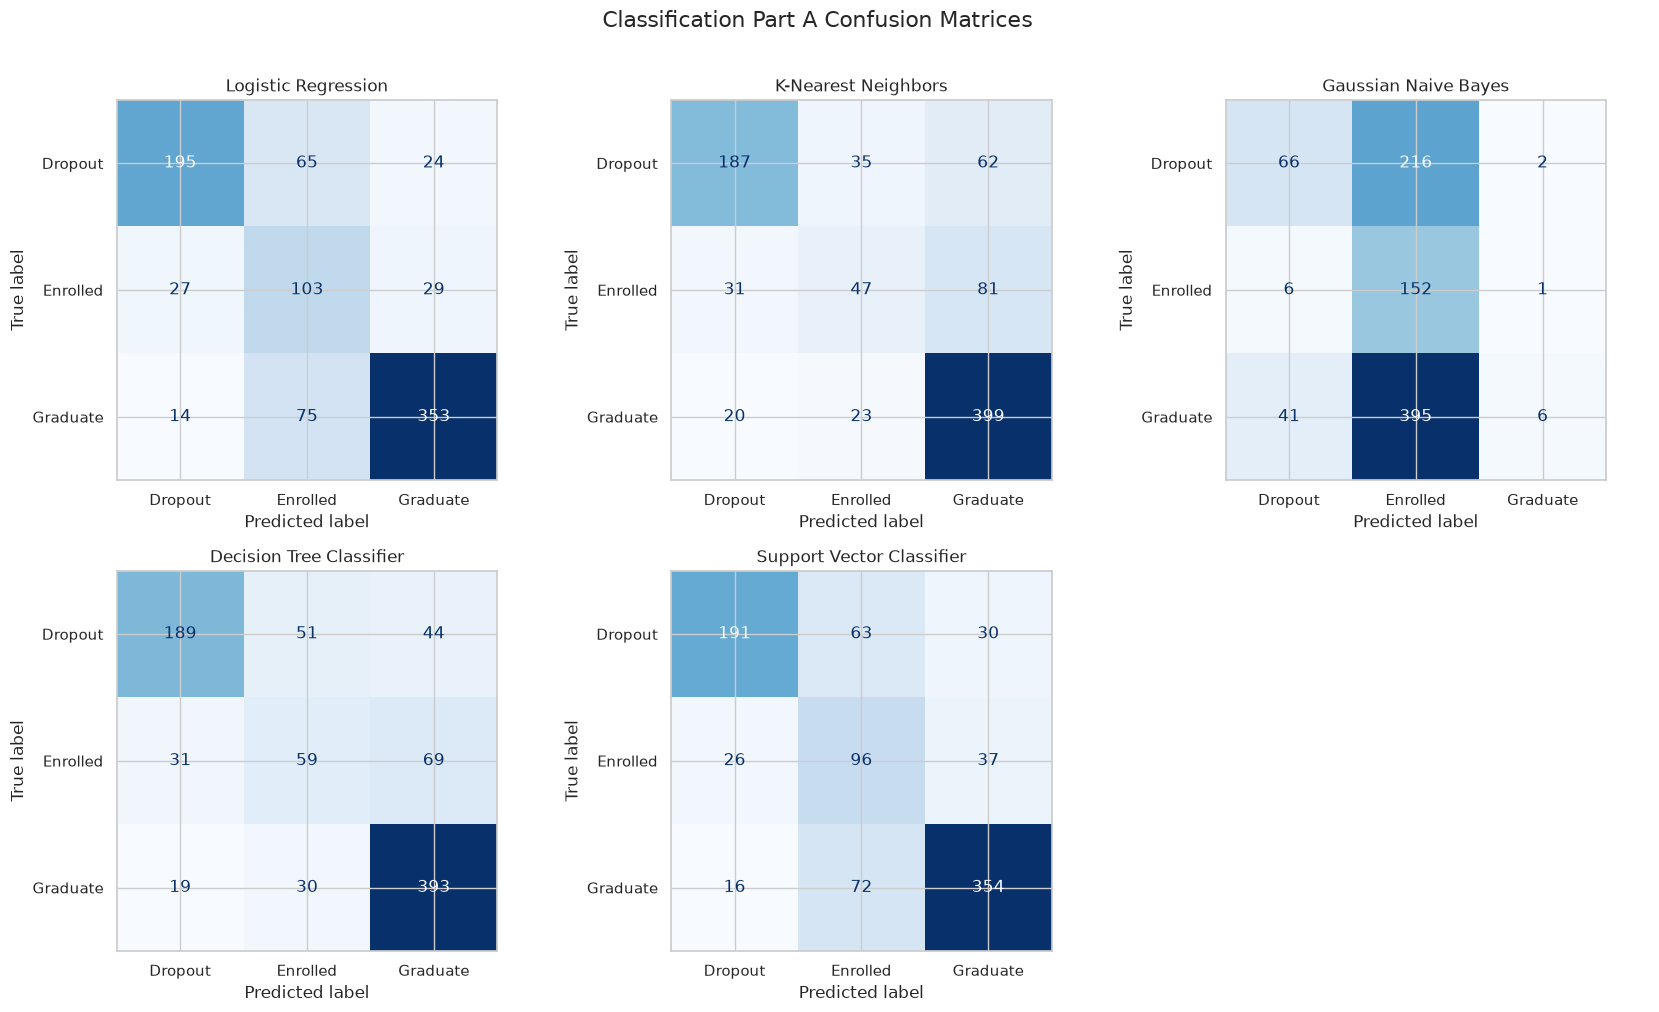

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for axis, (name, predictions) in zip(
    axes.flat,
    classification_predictions.items(),
):
    matrix = confusion_matrix(y_test, predictions, labels=class_order)
    ConfusionMatrixDisplay(matrix, display_labels=class_order).plot(
        ax=axis, cmap="Blues", colorbar=False, values_format="d"
    )
    axis.set_title(name)
axes.flat[-1].axis("off")
fig.suptitle("Classification Part A Confusion Matrices", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** The confusion matrices must be read by row: each row is an actual class and each column is a prediction. The `Enrolled` row is especially important because aggregate accuracy can remain high while this smaller, transitional group is confused with `Dropout` or `Graduate`.

## 17. Multiclass One-vs-Rest ROC curves

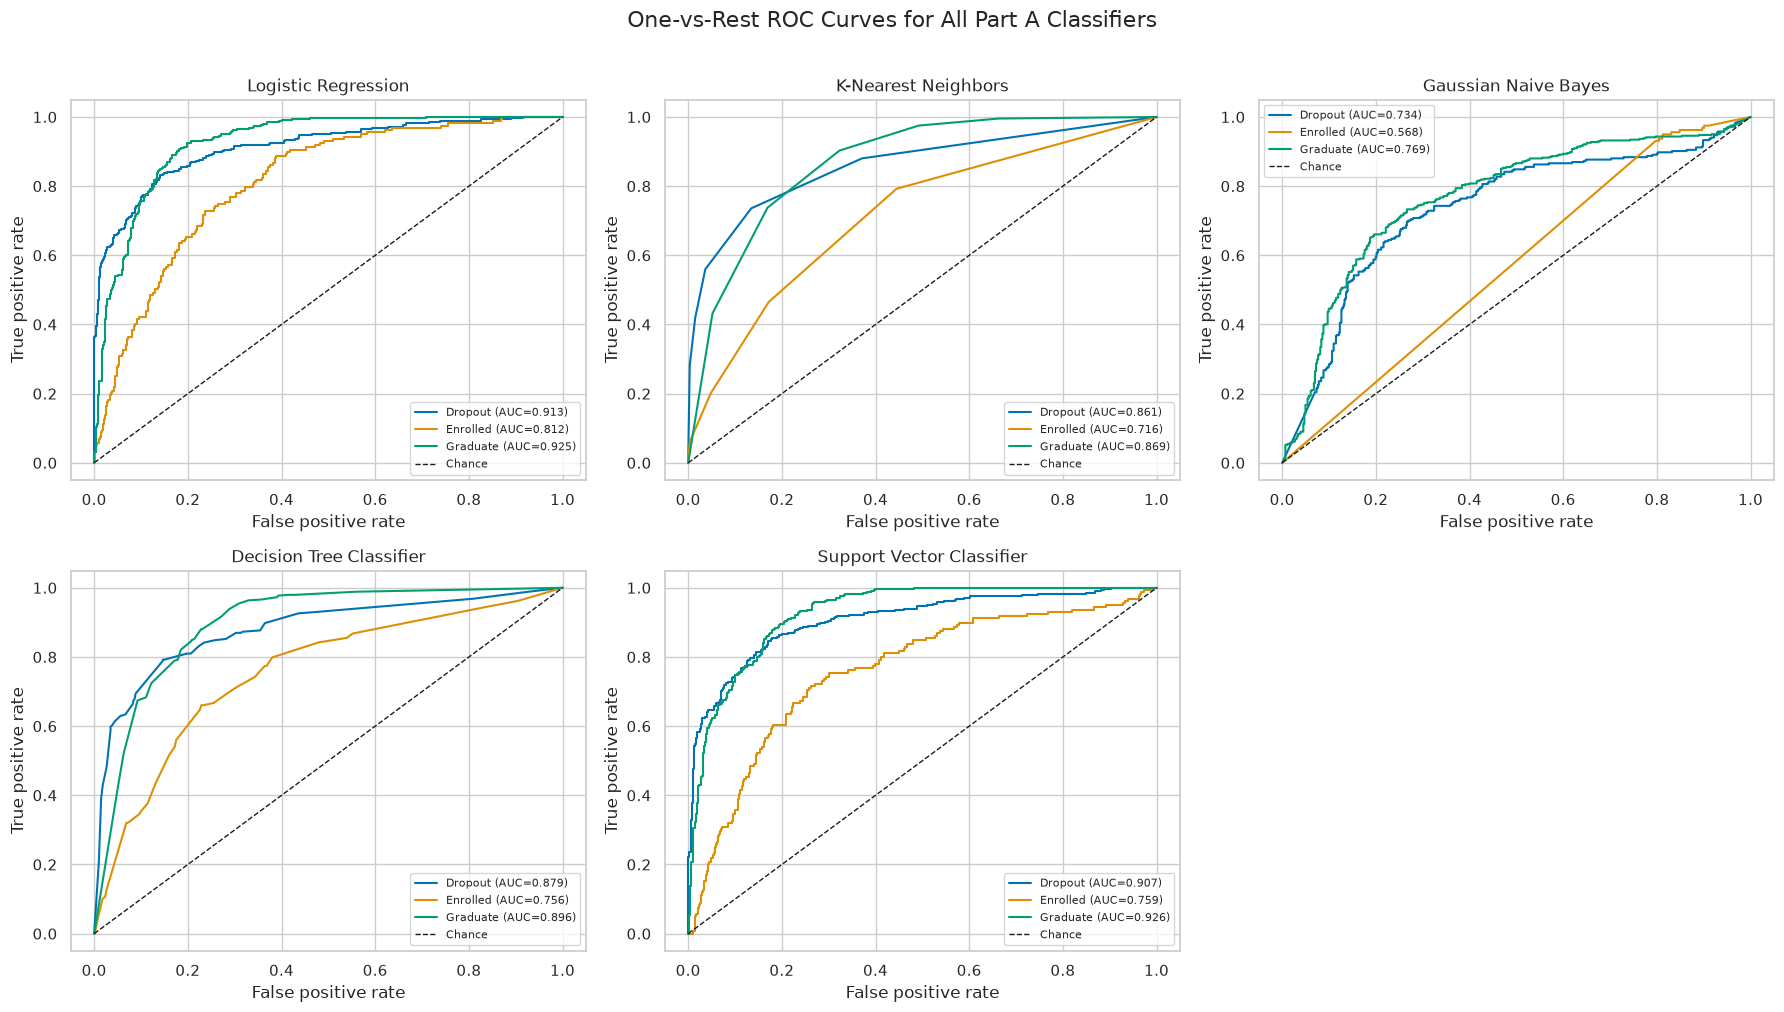

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for axis, name in zip(axes.flat, classification_estimators):
    scores = classification_scores[name]
    for class_index, label in enumerate(class_order):
        false_positive_rate, true_positive_rate, _ = roc_curve(
            y_test_binary[:, class_index], scores[:, class_index]
        )
        auc_value = roc_auc_score(y_test_binary[:, class_index], scores[:, class_index])
        axis.plot(false_positive_rate, true_positive_rate, label=f"{label} (AUC={auc_value:.3f})")
    axis.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")
    axis.set_title(name)
    axis.set_xlabel("False positive rate")
    axis.set_ylabel("True positive rate")
    axis.legend(fontsize=8)
axes.flat[-1].axis("off")
fig.suptitle("One-vs-Rest ROC Curves for All Part A Classifiers", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** OvR curves measure how well each model ranks one class against the other two. A strong aggregate AUC does not guarantee an acceptable decision threshold or minority-class recall, so ROC-AUC is interpreted together with the confusion matrices and per-class table.

## 18. Five-fold evidence for the two CV leaders

In [22]:
top_two_names = classification_cv_table.head(2)["Model"].tolist()
top_two_rows = []
for name in top_two_names:
    fold_scores = cross_val_score(
        clone(classification_estimators[name]),
        X_train_model,
        y_train,
        cv=stratified_cv,
        scoring="f1_macro",
        n_jobs=-1,
        error_score="raise",
    )
    row = {
        "Model": name,
        "Mean CV Macro F1": fold_scores.mean(),
        "Std CV Macro F1": fold_scores.std(),
    }
    row.update({f"Fold {index} Macro F1": score for index, score in enumerate(fold_scores, start=1)})
    top_two_rows.append(row)
classification_top2_cv = pd.DataFrame(top_two_rows)
display(classification_top2_cv.style.format({
    column: "{:.6f}" for column in classification_top2_cv.columns if "F1" in column
}))

FINAL_CLASSIFICATION_MODEL_NAME = top_two_names[0]
HELDOUT_CLASSIFICATION_LEADER = classification_comparison.iloc[0]["Model"]
print(f"Final candidate selected by training CV: {FINAL_CLASSIFICATION_MODEL_NAME}")
print(f"Highest held-out weighted F1: {HELDOUT_CLASSIFICATION_LEADER}")

,Model,Mean CV Macro F1,Std CV Macro F1,Fold 1 Macro F1,Fold 2 Macro F1,Fold 3 Macro F1,Fold 4 Macro F1,Fold 5 Macro F1
0,Support Vector Classifier,0.715701,0.015749,0.740079,0.719187,0.718194,0.691390,0.709656
1,Logistic Regression,0.714371,0.015983,0.724544,0.731637,0.725583,0.693845,0.696243


Final candidate selected by training CV: Support Vector Classifier
Highest held-out weighted F1: Logistic Regression


## 19. Logistic Regression coefficient evidence

In [23]:
logistic_estimator = classification_estimators["Logistic Regression"]
logistic_feature_names = logistic_estimator.named_steps["preprocessor"].get_feature_names_out()
logistic_model = logistic_estimator.named_steps["model"]
coefficient_rows = []
for class_index, label in enumerate(logistic_model.classes_):
    class_coefficients = pd.Series(
        logistic_model.coef_[class_index],
        index=logistic_feature_names,
    )
    for feature, value in class_coefficients.nlargest(8).items():
        coefficient_rows.append(
            {
                "Class": label,
                "Feature": feature,
                "Coefficient": value,
                "Odds multiplier": np.exp(value),
            }
        )
logistic_top_coefficients = pd.DataFrame(coefficient_rows)
display(logistic_top_coefficients.style.format({
    "Coefficient": "{:.4f}", "Odds multiplier": "{:.3f}"
}))

,Class,Feature,Coefficient,Odds multiplier
0,Dropout,Tuition fees up to date_0,0.7799,2.181
1,Dropout,Course_9853,0.5850,1.795
2,Dropout,Curricular units 2nd sem (enrolled),0.5711,1.770
3,Dropout,Course_9130,0.5266,1.693
4,Dropout,Mother's occupation_0,0.5266,1.693
5,Dropout,Father's occupation_90,0.4097,1.506
6,Dropout,Curricular units 1st sem (enrolled),0.3692,1.447
7,Dropout,Mother's qualification_34,0.3507,1.420
8,Enrolled,Course_9119,0.6052,1.832
9,Enrolled,Mother's occupation_191,0.4236,1.527


**Coefficient caution:** Positive coefficients raise the fitted log-odds for the named class relative to the multinomial alternatives, conditional on all transformed features. Numeric inputs are standardised, while one-hot coefficients compare a category with the omitted encoding baseline. They are associations, not causal effects.

## 20. Decision Tree readable upper levels

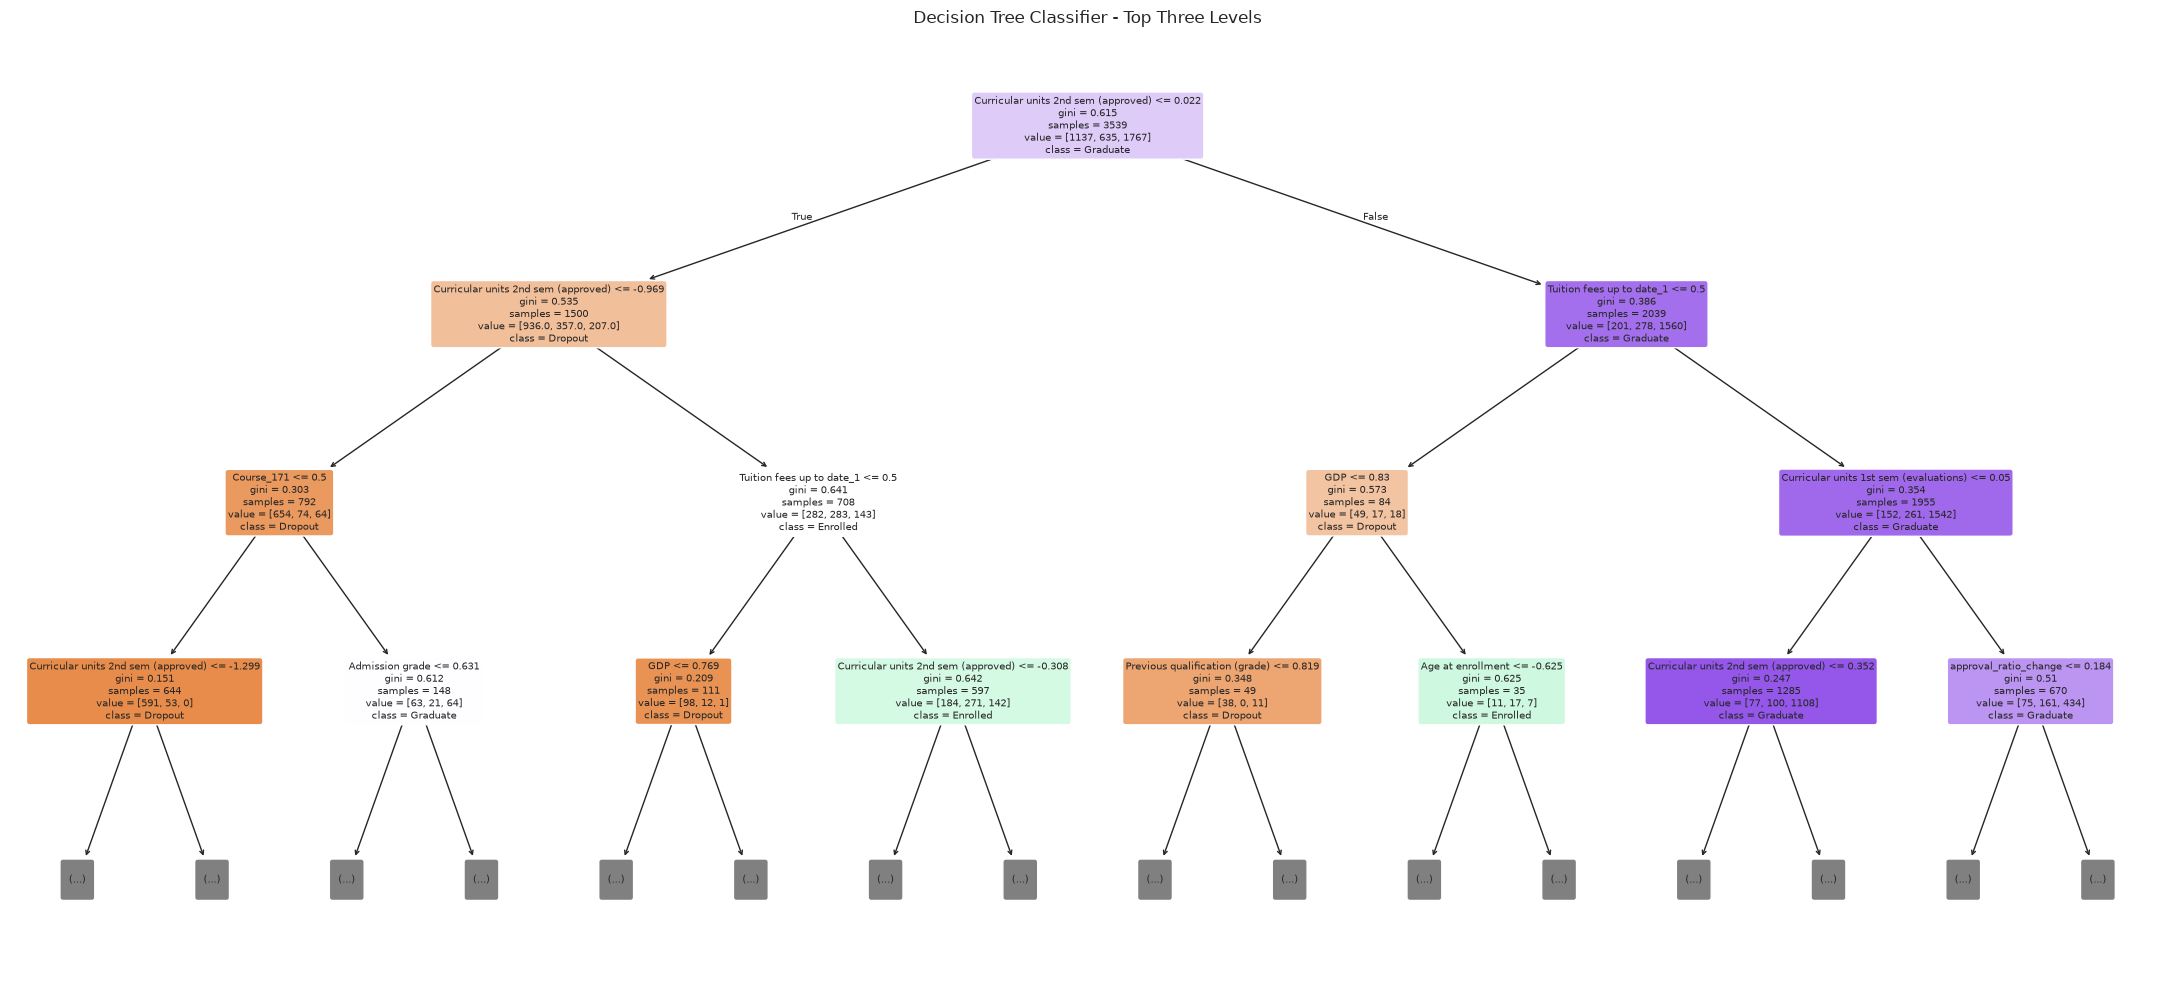

In [24]:
tree_estimator = classification_estimators["Decision Tree Classifier"]
tree_feature_names = tree_estimator.named_steps["preprocessor"].get_feature_names_out()
tree_model = tree_estimator.named_steps["model"]
plt.figure(figsize=(22, 10))
plot_tree(
    tree_model,
    feature_names=tree_feature_names,
    class_names=tree_model.classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=7,
)
plt.title("Decision Tree Classifier - Top Three Levels")
plt.tight_layout()
plt.show()

**Interpretation:** Only the top three levels are displayed so the main split logic remains readable. The fitted tree may contain deeper nodes according to the CV-selected depth; the visual is an explanation aid rather than a complete drawing of every leaf.

## 21. Basic subgroup error audit

In [25]:
selected_predictions = classification_predictions[FINAL_CLASSIFICATION_MODEL_NAME]
subgroup_frame = pd.DataFrame(
    {
        "Gender code": X_test_model["Gender"].to_numpy(),
        "Actual": y_test.to_numpy(),
        "Predicted": selected_predictions,
    }
)
subgroup_rows = []
for gender_code, group in subgroup_frame.groupby("Gender code"):
    subgroup_rows.append(
        {
            "Gender code": gender_code,
            "Rows": len(group),
            "Accuracy": accuracy_score(group["Actual"], group["Predicted"]),
            "Macro F1": f1_score(group["Actual"], group["Predicted"], average="macro", zero_division=0),
            "Error rate": 1 - accuracy_score(group["Actual"], group["Predicted"]),
        }
    )
classification_subgroup_audit = pd.DataFrame(subgroup_rows)
display(classification_subgroup_audit.style.format({
    "Accuracy": "{:.4f}", "Macro F1": "{:.4f}", "Error rate": "{:.4f}"
}))

,Gender code,Rows,Accuracy,Macro F1,Error rate
0,0,570,0.7386,0.6880,0.2614
1,1,315,0.6984,0.6684,0.3016


**Responsible-use interpretation:** Different subgroup error rates are a warning to investigate, not a fairness certification or proof of discrimination. The source uses binary gender coding and comes from one Portuguese institution; sample composition, omitted variables, and intersectional groups are not captured by this small audit. Predictions must remain human-reviewed support signals.

## 22. Final Classification Part A conclusion

In [26]:
final_cv_row = classification_cv_table.set_index("Model").loc[FINAL_CLASSIFICATION_MODEL_NAME]
final_test_row = classification_comparison.set_index("Model").loc[FINAL_CLASSIFICATION_MODEL_NAME]
heldout_row = classification_comparison.set_index("Model").loc[HELDOUT_CLASSIFICATION_LEADER]
enrolled_recall = classification_per_class.query(
    "Model == @FINAL_CLASSIFICATION_MODEL_NAME and Class == 'Enrolled'"
)["Recall"].iloc[0]
display(
    Markdown(
        f"`{FINAL_CLASSIFICATION_MODEL_NAME}` was preselected by mean training-CV macro F1 "
        f"`{final_cv_row['CV Mean Macro F1']:.4f}` (SD "
        f"`{final_cv_row['CV Std Macro F1']:.4f}`). On the untouched test set it achieved "
        f"accuracy `{final_test_row['Accuracy']:.4f}`, weighted F1 "
        f"`{final_test_row['Weighted F1']:.4f}`, macro F1 `{final_test_row['Macro F1']:.4f}`, "
        f"weighted OvR ROC-AUC `{final_test_row['Weighted OvR ROC-AUC']:.4f}`, and "
        f"`Enrolled` recall `{enrolled_recall:.4f}`. `{HELDOUT_CLASSIFICATION_LEADER}` had the "
        f"highest descriptive held-out weighted F1 (`{heldout_row['Weighted F1']:.4f}`). "
        "The smaller Enrolled-class recall remains a central limitation and must not be hidden by accuracy."
    )
)

`Support Vector Classifier` was preselected by mean training-CV macro F1 `0.7157` (SD `0.0157`). On the untouched test set it achieved accuracy `0.7243`, weighted F1 `0.7353`, macro F1 `0.6839`, weighted OvR ROC-AUC `0.8902`, and `Enrolled` recall `0.6038`. `Logistic Regression` had the highest descriptive held-out weighted F1 (`0.7485`). The smaller Enrolled-class recall remains a central limitation and must not be hidden by accuracy.

## 23. Exported classification evidence

In [27]:
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
classification_comparison.to_csv(RESULTS_DIR / "classification_model_comparison.csv", index=False)
classification_parameter_table.to_csv(RESULTS_DIR / "classification_best_parameters.csv", index=False)
classification_per_class.to_csv(RESULTS_DIR / "classification_per_class_metrics.csv", index=False)
classification_top2_cv.to_csv(RESULTS_DIR / "classification_top2_cv.csv", index=False)
classification_subgroup_audit.to_csv(RESULTS_DIR / "classification_subgroup_audit.csv", index=False)
print("Exported five classification result tables to results/.")

Exported five classification result tables to results/.


## 24. Classification limitations and handoff

- The data describes one Portuguese institution and requires external validation elsewhere.
- The prediction point is after semester two; this is not an enrollment-time early-warning model.
- Class probabilities or decision scores are predictive associations, not causal explanations.
- `Enrolled` is the smallest and most ambiguous class, so its recall must remain visible.
- Subgroup metrics are descriptive and incomplete; they do not establish fairness.
- The team must independently validate every interpretation before the review.